## Seller Account Health Risk Prediction Using Decision Trees

## Scope

This project applies a Decision Tree Classifier to predict whether an Amazon 
seller's account is Healthy or At Risk based on their operational performance 
metrics. The 'Synthetic' dataset consists of 1000 sellers with features covering defect 
rates, shipment performance, policy violations, and seller profile attributes.

The scope is limited to binary classification using a single Decision Tree — 
no ensemble methods, no hyperparameter tuning beyond starting values. The 
goal is to understand how a tree makes decisions, interpret its logic through 
visualization, and validate findings against real Amazon seller domain knowledge.

In [18]:
# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.tree import DecisionTreeClassifier

# Tree Visualization
from sklearn.tree import plot_tree

# Train Data Split
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

In [19]:
# Load the dataset
df = pd.read_csv(r"C:\Users\PRIYA SAVIO\Downloads\seller_account_health_final.csv")

df.head(5)

,seller_id,seller_category,fulfillment_type,order_defect_rate,late_shipment_rate,return_rate,negative_feedback_rate,policy_violation_count,account_status
0,AAJI0Y6DPBHSA,Books,FBM,0.0060,0.0476,0.0595,0.0194,1,0
1,AZZPQK51FPKH1,Beauty,FBM,0.0030,0.0732,0.0554,0.0160,0,0
2,ADD4V30T9NT3W,Toys & Games,FBA,0.0064,0.0050,0.1523,0.0240,1,0
3,AUZBIKCIDKWNNH,Books,FBA,0.0019,0.0005,0.0279,0.0071,0,0
4,AZYCWTIQJ7YHL1,Home & Kitchen,FBA,0.0014,0.0005,0.0692,0.0205,0,0


In [20]:
df.shape

(1000, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               1000 non-null   object 
 1   seller_category         1000 non-null   object 
 2   fulfillment_type        1000 non-null   object 
 3   order_defect_rate       1000 non-null   float64
 4   late_shipment_rate      1000 non-null   float64
 5   return_rate             1000 non-null   float64
 6   negative_feedback_rate  1000 non-null   float64
 7   policy_violation_count  1000 non-null   int64  
 8   account_status          1000 non-null   int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 70.4+ KB


In [22]:
df.describe()

,order_defect_rate,late_shipment_rate,return_rate,negative_feedback_rate,policy_violation_count,account_status
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.004138,0.014329,0.073756,0.010700,0.641000,0.219000
std,0.004451,0.021751,0.059086,0.011933,1.073905,0.413776
min,0.000500,0.000500,0.005000,0.001000,0.000000,0.000000
25%,0.001100,0.001600,0.030900,0.001000,0.000000,0.000000
50%,0.002700,0.004900,0.058950,0.007200,0.000000,0.000000
75%,0.005600,0.018075,0.101300,0.015300,1.000000,0.000000
max,0.032700,0.191400,0.325800,0.105300,5.000000,1.000000


In [23]:
# Check class balance — how many Healthy vs At Risk

print(df['account_status'].value_counts())

account_status
0    781
1    219
Name: count, dtype: int64


In [24]:
# finding any null values
df.isnull().sum()

seller_id                 0
seller_category           0
fulfillment_type          0
order_defect_rate         0
late_shipment_rate        0
return_rate               0
negative_feedback_rate    0
policy_violation_count    0
account_status            0
dtype: int64

In [25]:
for col in df.columns:
    if col == "seller_id":
        continue
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].unique()}")

seller_category: ['Books' 'Beauty' 'Toys & Games' 'Home & Kitchen' 'Grocery' 'Apparel'
 'Sports & Outdoors' 'Electronics']
fulfillment_type: ['FBM' 'FBA']


In [26]:
# preprocessing
# removing the column seller id as its not required 
df.drop(columns='seller_id', inplace= True)

In [27]:
# Applying label encoding to the columns seller_category and fulfillment_type

le_sc = LabelEncoder()  #le_sc = LabelEncoder_seller_category
df['seller_category'] = le_sc.fit_transform(df['seller_category'])

print("seller_category_mapping: ", dict(zip(le_sc.classes_,le_sc.transform(le_sc.classes_))))

le_ft = LabelEncoder() #le_ft = LabelEncoder_fulfillment_type
df['fulfillment_type'] = le_ft.fit_transform(df['fulfillment_type'])

print('fulfillment type: ', dict(zip(le_ft.classes_,le_ft.transform(le_ft.classes_))))

seller_category_mapping:  {'Apparel': 0, 'Beauty': 1, 'Books': 2, 'Electronics': 3, 'Grocery': 4, 'Home & Kitchen': 5, 'Sports & Outdoors': 6, 'Toys & Games': 7}
fulfillment type:  {'FBA': 0, 'FBM': 1}


In [28]:
# Seperate the input and target variables

X = df.drop(columns=['account_status']) #taking all columns except account status which is our target
y = df['account_status']

# splitting train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X,y,                                   # take X and y
    test_size= 0.2,                        # 80 Train 20 test split
    random_state= 42,                      # pick the same random
    stratify= y)                           # maintain same propotion

In [29]:
# Confirm shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.value_counts())
print("y_test:", y_test.value_counts())

X_train: (800, 7)
X_test: (200, 7)
y_train: account_status
0    625
1    175
Name: count, dtype: int64
y_test: account_status
0    156
1     44
Name: count, dtype: int64


#### Train the model

In [30]:
dt = DecisionTreeClassifier(
    criterion= 'gini',      # splitting criteria
    max_depth= 4,           # max levels the tree can grow
    min_samples_leaf= 10,   # minimum rows required at a leaf node
    random_state= 42)       # reproducibility

# Train the model

dt.fit(X_train,y_train)

print ("Model Trained")

Model Trained


#### Make Predictions

In [31]:
y_pred = dt.predict(X_test)

#### Evaluation

In [32]:
# Accuracy
print("Accuracy: ", accuracy_score(y_test, y_pred))

# confusion matrix
print('\nConfusion Matrix: ', confusion_matrix(y_test, y_pred))

# classification report
print('\nClassification Report: ', classification_report(y_test, y_pred, target_names=['Healthy', 'At Risk']))

Accuracy:  0.955

Confusion Matrix:  [[153   3]
 [  6  38]]

Classification Report:                precision    recall  f1-score   support

     Healthy       0.96      0.98      0.97       156
     At Risk       0.93      0.86      0.89        44

    accuracy                           0.95       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.95      0.95      0.95       200



##### Accuracy sores

#### Visualize the Decision Tree

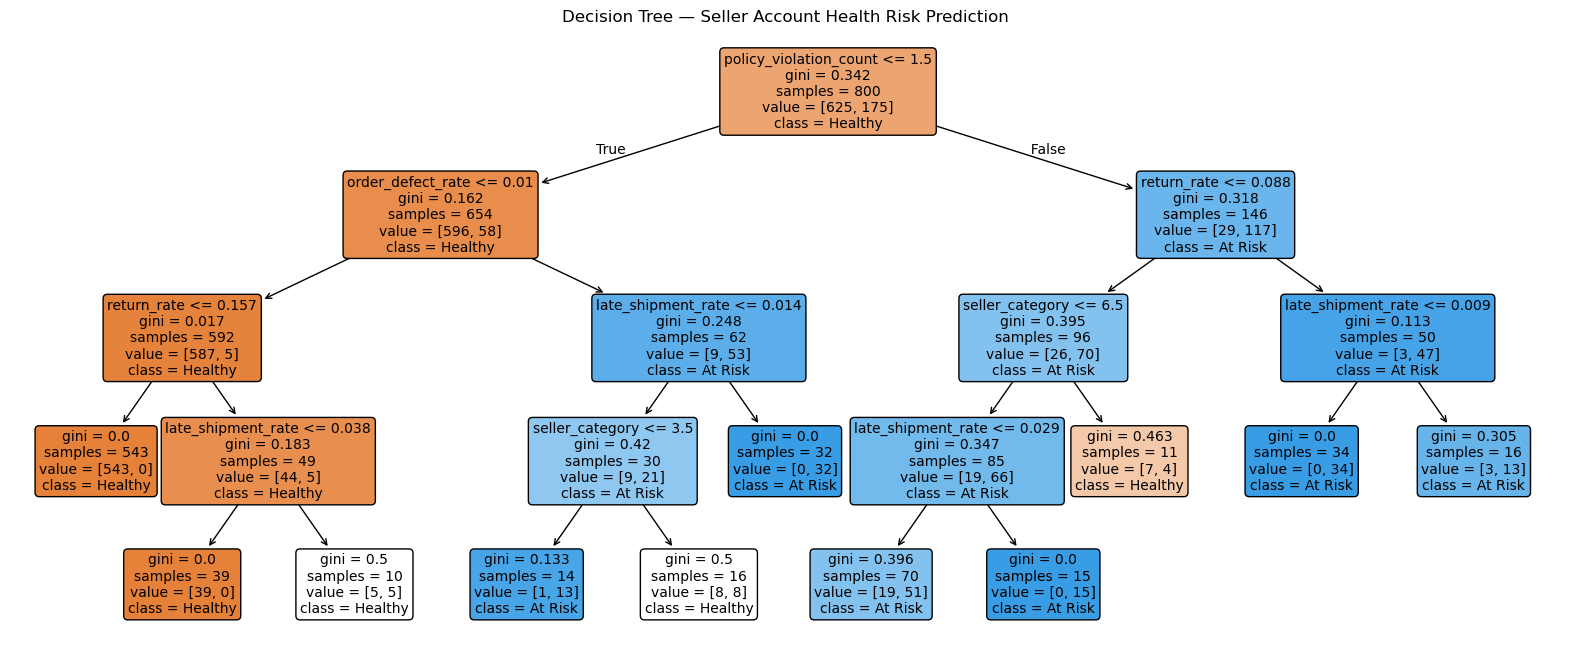

In [33]:
plt.figure(figsize= (20,8))

plot_tree(dt,
          feature_names= X.columns,
          class_names= ['Healthy', 'At Risk'],
          filled = True,
          rounded = True,
          fontsize= 10)

plt.title("Decision Tree — Seller Account Health Risk Prediction")
plt.show()

Feature Importances:
policy_violation_count    0.548799
order_defect_rate         0.363963
late_shipment_rate        0.042330
seller_category           0.027442
return_rate               0.017466
fulfillment_type          0.000000
negative_feedback_rate    0.000000
dtype: float64


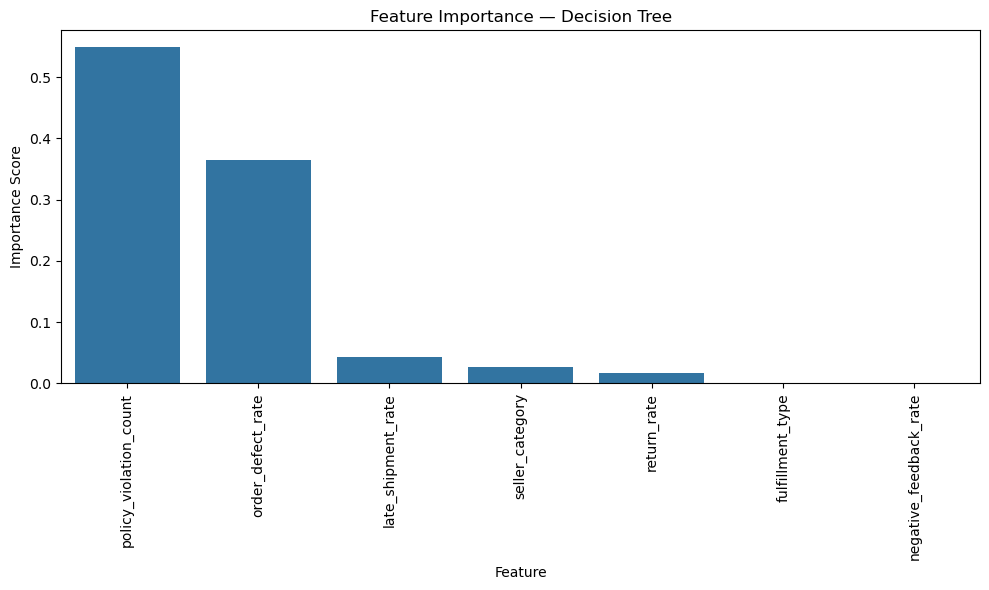

In [34]:
# Get feature importance scores
feature_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importances:")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(y=feature_importance.values, x=feature_importance.index)
plt.title("Feature Importance — Decision Tree")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

## Conclusion

Project 4 tested whether a Decision Tree could predict seller account risk 
from performance metrics alone. At 95.5% accuracy, it did the job well.

The model leaned heavily on policy_violation_count and order_defect_rate — 
together driving 91% of all splits. From an Amazon seller operations 
standpoint, this makes complete sense. These are the exact metrics Amazon 
flags first during account health reviews.

fulfillment_type and negative_feedback_rate contributed zero — the tree 
never found them useful enough to split on. More interestingly, 6 At Risk 
sellers were predicted as Healthy — in a real context, those are the ones 
that would slip through the cracks.

The tree visualization stood out — seeing the actual decision path node by 
node is something most algorithms don't offer. That interpretability is 
where Decision Trees genuinely earn their place.